<a href="https://colab.research.google.com/github/rafa177slp/mineriaDatos/blob/main/parleyLigamx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prediccion liga mx con random forest

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree


In [2]:

df = pd.read_csv('dataset_liga_mx_jornadas_13_14_15_base.csv')



In [3]:
# features y etiqueta
features = ['diff_puntos', 'diff_racha', 'diff_posicion']
x = df[features]
y = df['resultado']

diff_puntos 0.364
diff_racha 0.3
diff_posicion 0.336


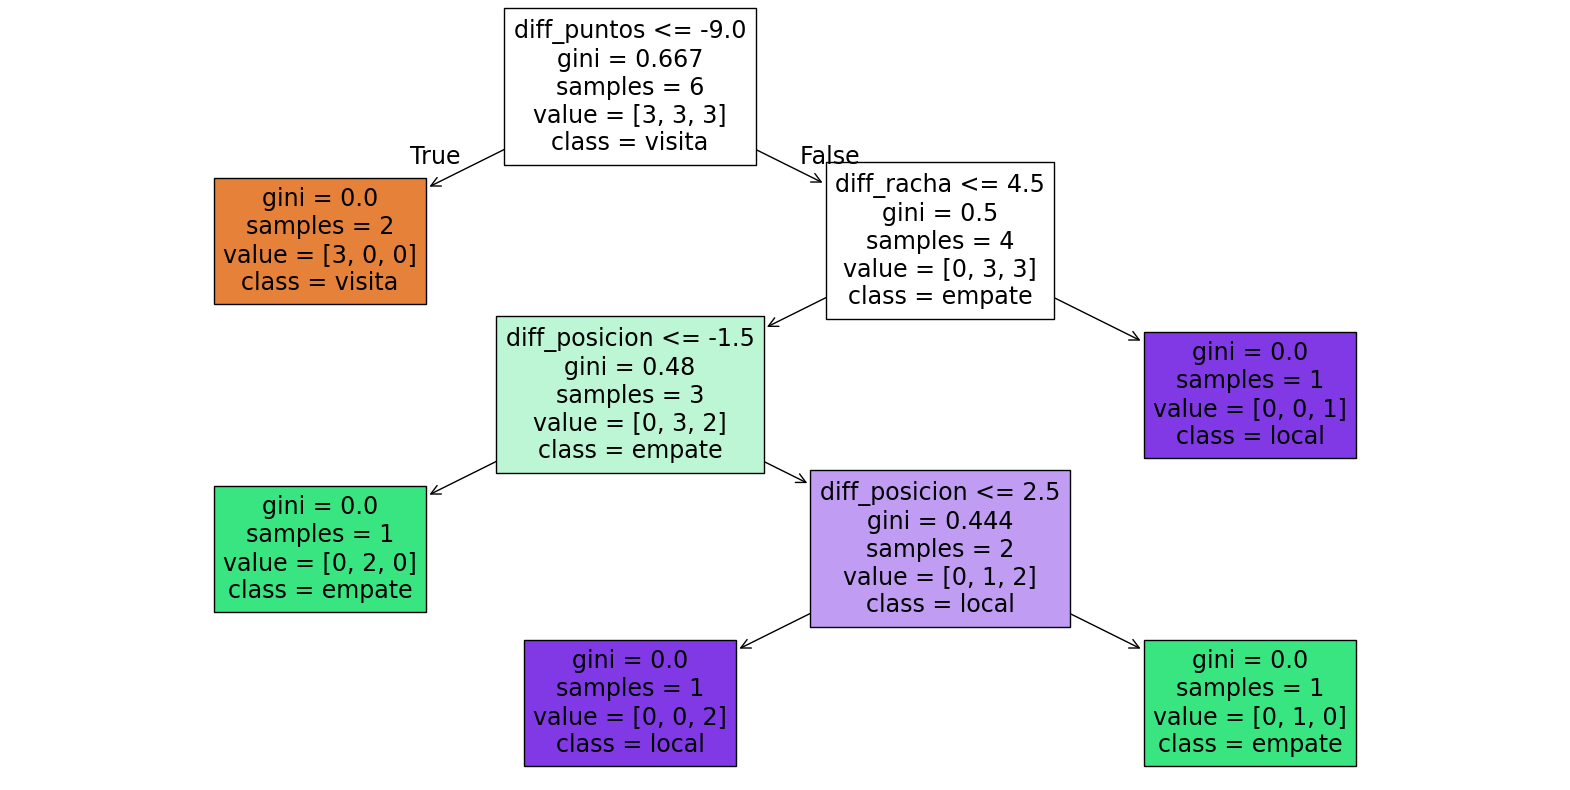

In [4]:
# entrenar modelo
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(x, y)

for f, imp in zip(features, rf.feature_importances_):
    print(f, round(imp, 3))

plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          feature_names=features,
          class_names=['visita', 'empate', 'local'],
          filled=True)
plt.show()

In [5]:
# sacar datos de cada equipo del csv
equipos = {}

for i in range(len(df)):
    fila = df.iloc[i]
    equipos[fila['equipo_local']] = [fila['local_puntos'],
                                     fila['local_racha'],
                                     fila['local_posicion']]
    equipos[fila['equipo_visita']] = [fila['visita_puntos'],
                                      fila['visita_racha'],
                                      fila['visita_posicion']]

In [6]:
# partidos jornada 16 (uso los mismos nombres del csv)
partidos = [
    ['Querétaro',         'Cruz Azul'],
    ['Pumas',             'FC Juárez'],
    ['Monterrey',         'Puebla'],
    ['León',              'América'],
    ['Atlas',             'Tigres'],
    ['Atlético San Luis', 'Santos'],
    ['Mazatlán',          'Toluca'],
    ['Necaxa',            'Chivas'],
    ['Tijuana',           'Pachuca']
]



In [7]:
# calcular diferencias
datos_j16 = []

for p in partidos:
    local = p[0]
    visita = p[1]

    dl = equipos[local]
    dv = equipos[visita]

    diff_puntos = dl[0] - dv[0]
    diff_racha = dl[1] - dv[1]
    diff_posicion = dv[2] - dl[2]

    datos_j16.append([diff_puntos, diff_racha, diff_posicion])



In [8]:
# predecir y mostrar
predicciones = rf.predict(datos_j16)

for i in range(len(partidos)):
    local = partidos[i][0]
    visita = partidos[i][1]
    p = predicciones[i]

    if p == 2:
        r = 'gana local'
    elif p == 1:
        r = 'empate'
    else:
        r = 'gana visita'

    print(local, 'vs', visita, '->', r)

Querétaro vs Cruz Azul -> gana visita
Pumas vs FC Juárez -> gana local
Monterrey vs Puebla -> gana local
León vs América -> empate
Atlas vs Tigres -> gana local
Atlético San Luis vs Santos -> gana local
Mazatlán vs Toluca -> gana visita
Necaxa vs Chivas -> gana visita
Tijuana vs Pachuca -> gana visita


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
